In [1]:
# %pip install pandas
# %pip install matplotlib
# %pip install seaborn


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# читаем данные
df = pd.read_csv("results.csv")
df

,n,procs,time
0,100,1,0.000006
1,100,2,0.000058
2,100,4,0.000026
3,100,8,0.000160
4,1000,1,0.000019
5,1000,2,0.000037
6,1000,4,0.000053
7,1000,8,0.000027
8,10000,1,0.000140
9,10000,2,0.000185


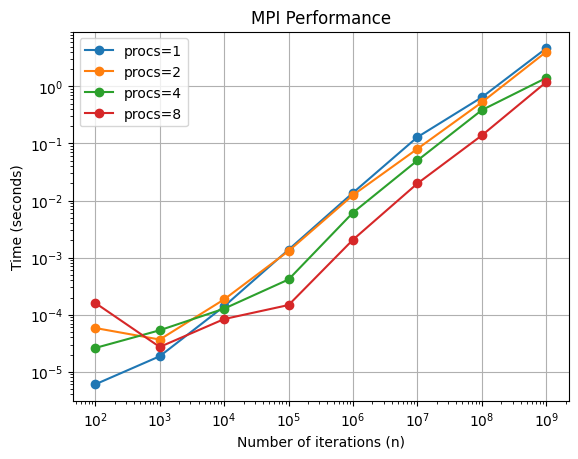

In [3]:
# уникальные значения процессов
proc_values = df["procs"].unique()

for p in proc_values:
    subset = df[df["procs"] == p].sort_values("n")

    plt.plot(subset["n"], subset["time"], marker='o', label=f"procs={p}")

plt.xlabel("Number of iterations (n)")
plt.ylabel("Time (seconds)")
plt.title("MPI Performance")
plt.legend()
plt.grid()
plt.xscale("log")
plt.yscale("log")

plt.show()

In [4]:
# время на 1 ядре
baseline = df[df.procs == 1][["n","time"]].rename(columns={"time":"time1"})

df_speed = df.merge(baseline, on="n")
df_speed["speedup"] = df_speed["time1"] / df_speed["time"]

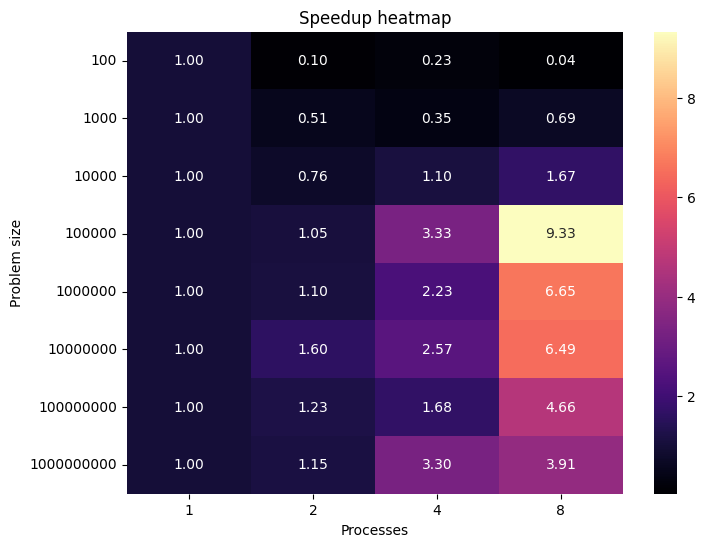

In [6]:
pivot_speed = df_speed.pivot(index="n", columns="procs", values="speedup")

plt.figure(figsize=(8,6))
sns.heatmap(pivot_speed, annot=True, fmt=".2f", cmap="magma")

plt.title("Speedup heatmap")
plt.xlabel("Processes")
plt.ylabel("Problem size")

plt.show()

In [8]:
0.0137 / 0.00206

6.650485436893203